In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

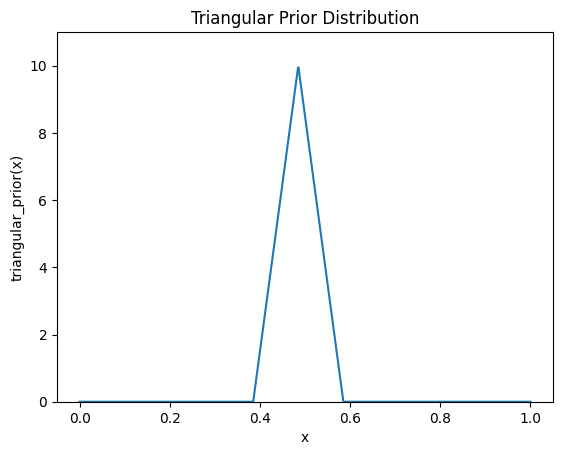

The center of the triangular distribution is 0.485


In [57]:
def triangular_prior(x: np.ndarray) -> np.ndarray:
    # 100(x-0.385) if x<0.485
    # 100(0.585-x) if x>=0.485
    # if f(x) < 0, return 0
    y = np.where(x<0.485, 100*(x-0.385), 100*(0.585-x))
    y = np.where(y<0, 0, y)
    return y

x = np.linspace(0, 1, 1000)
y = triangular_prior(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('triangular_prior(x)')
# limit the y-axis to 0-11
plt.ylim(0, 11)
plt.title('Triangular Prior Distribution')
plt.show()
# The center of the triangular distribution is 0.485
print(f'The center of the triangular distribution is 0.485')

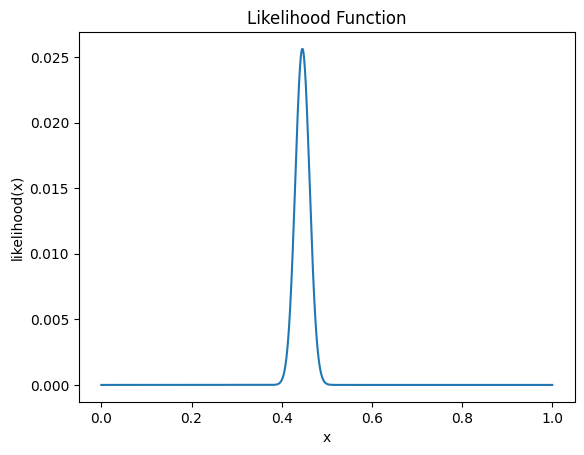

The MLE is 0.4459


In [58]:
# define the likelihood function
def likelihood(x: np.ndarray) -> np.ndarray:
    # binomial likelihood
    n = 980
    k = 437
    return st.binom.pmf(k, n, x)

# plot the likelihood function
y = likelihood(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('likelihood(x)')
plt.title('Likelihood Function')
plt.show()

# The MLE is k/n
mle = 437/980
print(f'The MLE is {mle:.4f}')

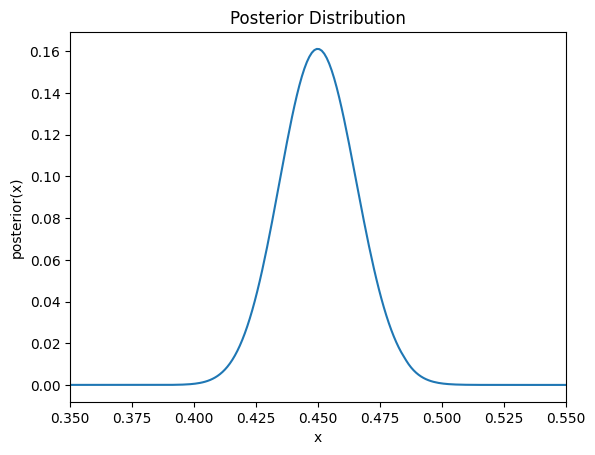

In [59]:
# define the posterior function
def posterior(x: np.ndarray) -> np.ndarray:
    return likelihood(x) * triangular_prior(x)

# plot the posterior function
x = np.linspace(0, 1, 1000)
y = posterior(x)
plt.plot(x, y)
plt.xlabel('x')
plt.xlim(0.35, 0.55)
plt.ylabel('posterior(x)')
plt.title('Posterior Distribution')
plt.show()

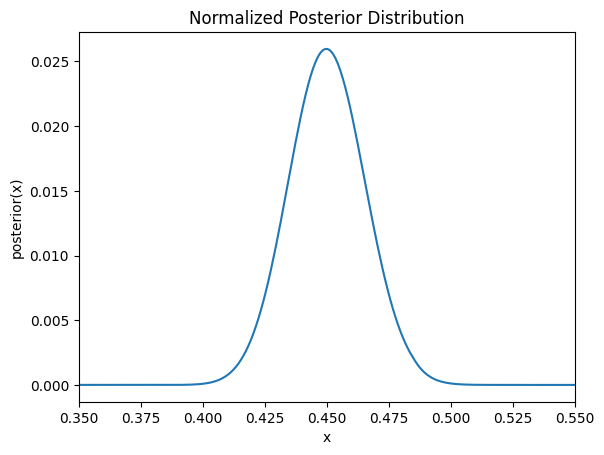

The median of the posterior distribution is 0.4505
The 95% credible interval is [0.4204, 0.4805]


In [60]:
# normalize the posterior function
x = np.linspace(0, 1, 1000)
y = posterior(x)
y = y / np.sum(y)
plt.plot(x, y)
plt.xlabel('x')
plt.xlim(0.35, 0.55)
plt.ylabel('posterior(x)')
plt.title('Normalized Posterior Distribution')
plt.show()
# median of the posterior distribution
print(f'The median of the posterior distribution is {x[np.argmax(np.cumsum(y) > 0.5)]:.4f}')
# 95% credible interval
lower_bound = x[np.argmax(np.cumsum(y) > 0.025)]
upper_bound = x[np.argmax(np.cumsum(y) > 0.975)]
print(f'The 95% credible interval is [{lower_bound:.4f}, {upper_bound:.4f}]')

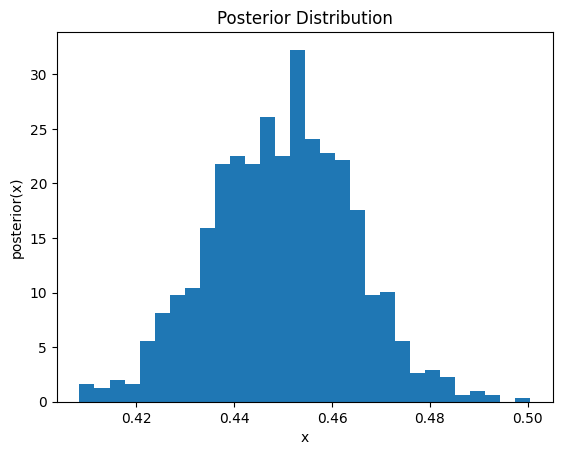

The median of the posterior distribution is 0.4505
The 95% credible interval is (0.4214, 0.4785)


In [61]:
# sample from the posterior distribution
size = 1000
x = np.linspace(0, 1, size)
y = posterior(x)
y[y < 0] = 0
y = y / np.sum(y)
samples = np.random.choice(x, size=size, p=y)
plt.hist(samples, bins=30, density=True)
plt.xlabel('x')
plt.ylabel('posterior(x)')
plt.title('Posterior Distribution')
plt.show()
lower = np.percentile(samples, 2.5)
middle = np.percentile(samples, 50)
upper = np.percentile(samples, 97.5)
print(f'The median of the posterior distribution is {middle:.4f}')
print(f'The 95% credible interval is ({lower:.4f}, {upper:.4f})')